# Week 07 (Lecture 2) — Pulse Sequences, Contrast & k-space Theory

Continuation of MR image formation. Topics: the **spin-echo** pulse sequence (vs gradient echo),
**image contrast** (T1/T2/PD weighting via TR/TE), **inversion recovery** (STIR/FLAIR),
deeper **k-space theory** (field-of-view, resolution, cropping → blur, undersampling → aliasing,
k-space filtering = convolution), and **BOLD / functional MRI**. Advanced sequences (phase-contrast
4D flow, diffusion-tensor imaging, MR spectroscopy, gadolinium contrast) are summarized at the end.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import camera

## 1. Spin echo vs gradient echo
A **gradient echo** rephases spins by *reversing the readout gradient* — it recovers only the
gradient-induced dephasing, so its envelope decays with **$T_2^*$** (includes field inhomogeneity).

A **spin echo** uses a **180° RF pulse** at time $TE/2$ to *flip* the spins (palm-on-table analogy:
fingers that were spreading now converge). Because the precession direction is unchanged, the
accumulated phase from **static field inhomogeneity reverses and refocuses** at the echo time $TE$.
The spin echo therefore removes $T_2^*$ dephasing and its echo peak follows the true **$T_2$**
envelope. **TR** is the time before the whole sequence repeats.

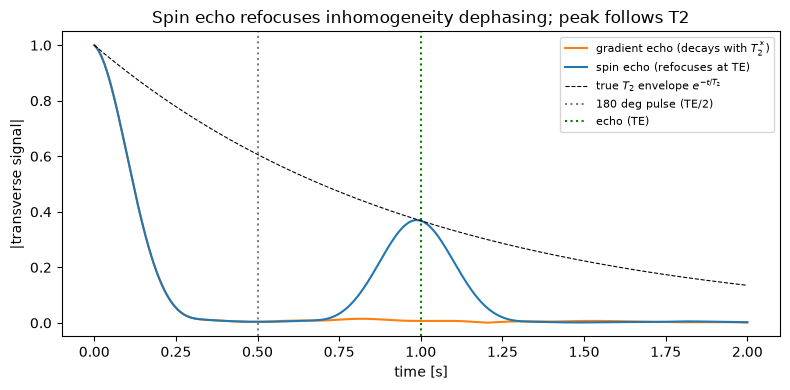

In [2]:
rng = np.random.default_rng(0)
n_iso = 3000
dw = rng.normal(0.0, 9.0, n_iso)      # static frequency offsets (field inhomogeneity) [rad/s]
T2 = 1.0                              # intrinsic transverse relaxation [s]
t = np.linspace(0, 2.0, 1500)
TE = 1.0                              # echo time; 180 deg pulse applied at TE/2

# Phase of each isochromat: accrues, then the 180 deg pulse at TE/2 negates it -> refocus at TE
phase = np.where(t[:, None] < TE / 2,
                 dw[None, :] * t[:, None],
                 dw[None, :] * (TE - t[:, None]))
S_SE = np.abs(np.mean(np.exp(1j * phase), axis=1)) * np.exp(-t / T2)
S_GE = np.abs(np.mean(np.exp(1j * dw[None, :] * t[:, None]), axis=1)) * np.exp(-t / T2)

plt.figure(figsize=(8, 4))
plt.plot(t, S_GE, color="tab:orange", label="gradient echo (decays with $T_2^*$)")
plt.plot(t, S_SE, color="tab:blue",  label="spin echo (refocuses at TE)")
plt.plot(t, np.exp(-t / T2), "k--", lw=0.8, label=r"true $T_2$ envelope $e^{-t/T_2}$")
plt.axvline(TE / 2, color="gray", ls=":", label="180 deg pulse (TE/2)")
plt.axvline(TE, color="green", ls=":", label="echo (TE)")
plt.xlabel("time [s]"); plt.ylabel("|transverse signal|")
plt.title("Spin echo refocuses inhomogeneity dephasing; peak follows T2")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 2. Image contrast: T1-, T2-, and PD-weighting
The spin-echo signal depends on three **tissue properties** (proton density $\rho$, $T_1$, $T_2$) and
two **operator controls** (TR, TE):
$$S \;\propto\; \rho\,\big(1 - e^{-TR/T_1}\big)\,e^{-TE/T_2}.$$

- **T1-weighted**: short TR, short TE — differences in $T_1$ dominate (fat bright, fluid dark).
- **T2-weighted**: long TR, long TE — differences in $T_2$ dominate (fluid bright).
- **PD-weighted**: long TR, short TE — differences in proton density dominate.

(The third control, **tip/flip angle**, set by RF pulse duration, also shapes contrast.)

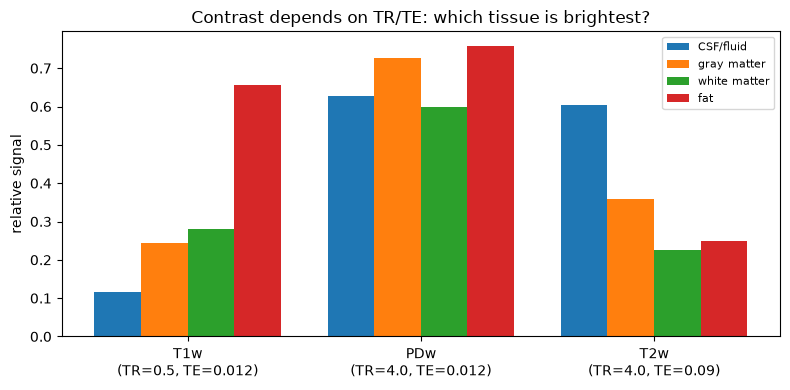

In [3]:
# (T1 [s], T2 [s], proton density [rel.])
tissues = {
    "CSF/fluid":    (4.0, 2.00, 1.00),
    "gray matter":  (1.3, 0.11, 0.85),
    "white matter": (0.8, 0.08, 0.70),
    "fat":          (0.25, 0.07, 0.90),
}

def se_signal(T1, T2, PD, TR, TE):
    return PD * (1 - np.exp(-TR / T1)) * np.exp(-TE / T2)

protocols = {
    "T1w\n(TR=0.5, TE=0.012)": (0.5, 0.012),
    "PDw\n(TR=4.0, TE=0.012)": (4.0, 0.012),
    "T2w\n(TR=4.0, TE=0.09)":  (4.0, 0.090),
}

names = list(tissues)
x = np.arange(len(protocols)); w = 0.2
fig, ax = plt.subplots(figsize=(8, 4))
for i, name in enumerate(names):
    T1, T2_, PD = tissues[name]
    vals = [se_signal(T1, T2_, PD, *protocols[p]) for p in protocols]
    ax.bar(x + (i - 1.5) * w, vals, w, label=name)
ax.set_xticks(x); ax.set_xticklabels(list(protocols))
ax.set_ylabel("relative signal"); ax.set_title("Contrast depends on TR/TE: which tissue is brightest?")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

## 3. Inversion recovery (STIR / FLAIR)
A 180° **inversion** pulse flips $M_z$ to $-M_0$; it then recovers as
$$M_z(t) = M_0\big(1 - 2e^{-t/T_1}\big).$$
Each tissue passes through **zero** at its null time $TI = T_1\ln 2$. By choosing the inversion time
$TI$ to null a specific tissue, we suppress it:
- **STIR** nulls **fat** (short $T_1$) — useful to unmask tumor next to fat (e.g. breast MRI).
- **FLAIR** nulls **fluid/CSF** (long $T_1$).

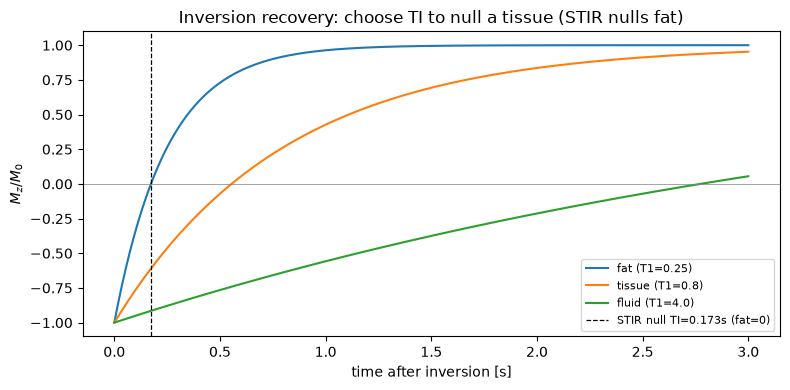

In [4]:
t = np.linspace(0, 3.0, 1000)
ir = {"fat (T1=0.25)": 0.25, 
"tissue (T1=0.8)": 0.8, "fluid (T1=4.0)": 4.0}

plt.figure(figsize=(8, 4))
for label, T1 in ir.items():
    Mz = 1 - 2 * np.exp(-t / T1)
    plt.plot(t, Mz, label=label)
TI_fat = 0.25 * np.log(2)                 # null time for fat (STIR)
plt.axvline(TI_fat, color="k", ls="--", lw=0.9, label=f"STIR null TI={TI_fat:.3f}s (fat=0)")
plt.axhline(0, color="gray", lw=0.5)
plt.xlabel("time after inversion [s]"); plt.ylabel("$M_z/M_0$")
plt.title("Inversion recovery: choose TI to null a tissue (STIR nulls fat)")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

## 4. k-space theory: field of view, resolution, cropping & undersampling
For an $N\times N$ image, the discrete k-space is an $N\times N$ **sampling of an infinite** spatial-
frequency plane (origin at the center).
- **More k-space points** → more image pixels in the **same field of view** → **better resolution**
  (smaller $\Delta x, \Delta y$).
- **Cropping to the center** of k-space (keeping only low frequencies) → same FOV but **blurrier**
  (fewer effective pixels / lost edges).
- **Undersampling** k-space (skipping lines) → **reduced FOV with aliasing / fold-over** (the rest of
  the object wraps into the image).

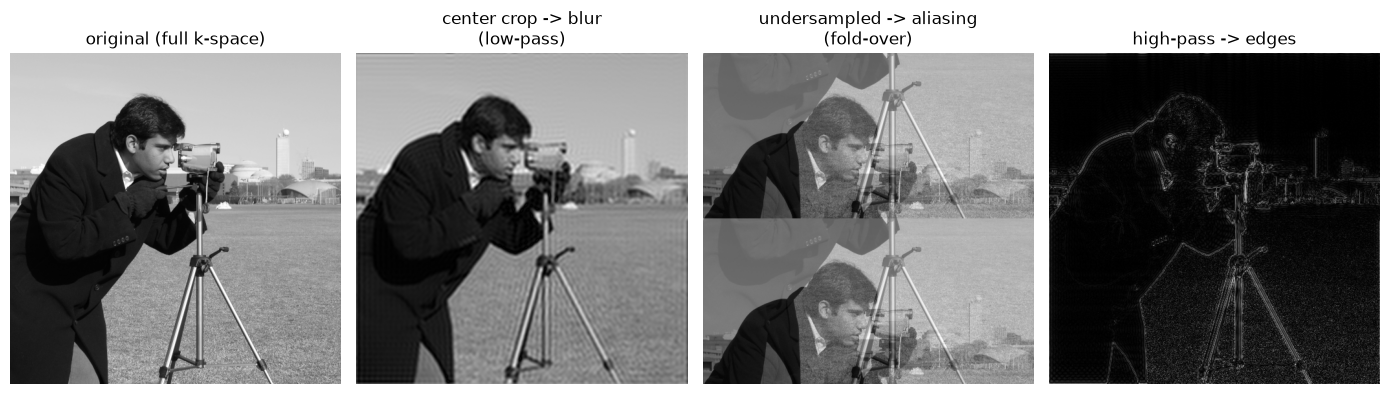

In [5]:
img = camera().astype(float)
img /= img.max()
ks = np.fft.fftshift(np.fft.fft2(img))
N = img.shape[0]

# (a) center crop -> low-pass -> blur (same FOV, fewer effective pixels)
frac = 0.12
c = N // 2; r = int(N * frac)
ks_crop = np.zeros_like(ks)
ks_crop[c-r:c+r, c-r:c+r] = ks[c-r:c+r, c-r:c+r]
blur = np.abs(np.fft.ifft2(np.fft.ifftshift(ks_crop)))

# (b) undersample (zero every other ky line) -> aliasing / fold-over
ks_us = ks.copy(); ks_us[1::2, :] = 0
alias = np.abs(np.fft.ifft2(np.fft.ifftshift(ks_us)))

# (c) high-pass (remove center) -> edges
ks_hp = ks.copy(); ks_hp[c-r:c+r, c-r:c+r] = 0
edges = np.abs(np.fft.ifft2(np.fft.ifftshift(ks_hp)))

fig, ax = plt.subplots(1, 4, figsize=(14, 4))
for a, im, ttl in zip(
        ax,
        (img, blur, alias, edges),
        ("original (full k-space)", "center crop -> blur\n(low-pass)",
         "undersampled -> aliasing\n(fold-over)", "high-pass -> edges")):
    a.imshow(im, cmap="gray"); a.set_title(ttl); a.axis("off")
plt.tight_layout(); plt.show()

Masking k-space down to its center is **equivalent to convolution (smoothing) in the image domain** —
the same low-pass filtering we did with the DICOM images in Weeks 1–2. Boosting the **outer** k-space
sharpens edges (high-frequency, rarer content). In **Assignment 3 Part 2** you will crop/brighten
k-space to blur and sharpen images.

## 5. BOLD / functional MRI
**BOLD** (blood-oxygen-level-dependent) contrast is a **$T_2^*$** effect. Neuronal activity raises
local blood flow, delivering more **oxyhemoglobin** (diamagnetic → less field distortion → **longer
$T_2^*$** → **brighter** signal), relative to **deoxyhemoglobin** (paramagnetic → shorter $T_2^*$).
The measured voxel time series is the stimulus convolved with the **hemodynamic response function
(HRF)** — a gamma-shaped bump.

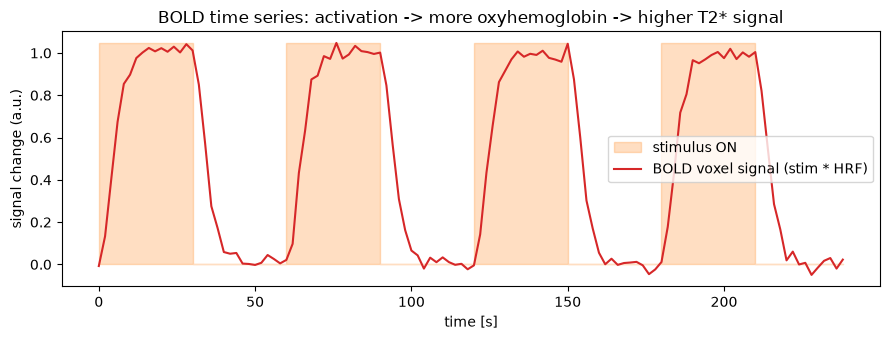

In [6]:
TR = 2.0
n = 120
t = np.arange(n) * TR                       # scan time [s]
stim = ((t // 30) % 2 == 0).astype(float)   # 30 s ON / 30 s OFF block design

# Gamma-shaped hemodynamic response function
th = np.arange(0, 30, TR)
hrf = (th ** 3) * np.exp(-th / 1.5)
hrf /= hrf.sum()
bold = np.convolve(stim, hrf)[:n]
bold += rng.normal(0, 0.02, n)              # measurement noise

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.fill_between(t, stim * bold.max(), step="post", color="tab:orange", alpha=0.25, label="stimulus ON")
ax.plot(t, bold, color="tab:red", label="BOLD voxel signal (stim * HRF)")
ax.set_xlabel("time [s]"); ax.set_ylabel("signal change (a.u.)")
ax.set_title("BOLD time series: activation -> more oxyhemoglobin -> higher T2* signal")
ax.legend(); plt.tight_layout(); plt.show()

## 6. Advanced sequences & Fourier theory (conceptual)
- **Phase-contrast MRI (4D flow):** phase is used as an encoding gradient to measure velocity in x, y,
  z at every voxel → a 3D velocity vector field (e.g. aortic blood flow), colored by speed.
- **Diffusion-tensor imaging (DTI):** measures water diffusion in ≥3 directions; water moves along
  myelinated axons, so diffusion direction reveals fiber orientation (color-coded) → tractography
  (Human Connectome Project).
- **MR spectroscopy:** the frequency (ppm) signature of the FID identifies chemical/tissue
  composition — biomarkers of disease, with optional spatial localization.
- **Gadolinium (Gd-DTPA):** a chelated contrast agent that locally **shortens $T_1$** (brightens on
  T1w); used for MR angiography and to localize blood-supplied tumors that breach the blood-brain
  barrier.
- **Fourier theory** underpins it all — MR k-space, CT/SPECT resolution, ultrasound beam design, and
  image artifacts — as the science of generating and detecting waves.

### Next
Next class: MATLAB exercises on the **k-space ↔ image** relationship, then **CT image formation**.